In [1]:
import os
import cantera as ct
import glob
import pickle
import yaml
import copy
import datetime
import fpdf
import rmgpy.chemkin
import numpy as np

import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
%matplotlib inline

import sys
sys.path.append(os.environ['DATABASE_DIR'])
import database_fun

import report

Loading DFT database from /projects/westgroup/harris.se/autoscience/reaction_calculator/database
hotbit not installed


In [2]:
report_image_dir = 'temp_images'
os.makedirs(report_image_dir, exist_ok=True)

In [3]:
my_chemkin = '/projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20251019/chem_annotated.inp'

In [4]:
def get_prev_run_folders(chemkin_file):
    fuel_name = os.path.basename(os.path.dirname(chemkin_file)).split('_')[0]
    run_dirs = sorted(glob.glob(os.path.join(os.path.dirname(os.path.dirname(chemkin_file)), f'{fuel_name}_*')))
    prev_run_dirs = []
    for i in range(len(run_dirs)):
        if run_dirs[i] > os.path.dirname(chemkin_file):
            continue
        prev_run_dirs.append(run_dirs[i])
    return prev_run_dirs

def get_i_thing(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    return -1

def get_i_things(thing, thing_list):
    things_found = []
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            things_found.append(i)
    return things_found

In [5]:
def get_reverse_reaction(reaction):
    assert reaction.kinetics is not None
    rev_reaction = copy.deepcopy(reaction)
    tmp_reactants = rev_reaction.reactants
    rev_reaction.reactants = rev_reaction.products
    rev_reaction.products = tmp_reactants
    rev_reaction.kinetics = reaction.generate_reverse_rate_coefficient()
    return rev_reaction

def reactions_in_same_direction(reaction1, reaction2):
    assert reaction1.is_isomorphic(reaction2), 'Reactions are not even isomorphic'
    if len(reaction1.reactants) != len(reaction2.reactants):
        return False
    reactants_to_match = [r for r in reaction1.reactants]
    counter = 0
    while reactants_to_match:
        for i in range(len(reaction2.reactants)):
            if reaction2.reactants[i].is_isomorphic(reactants_to_match[0]):
                reactants_to_match.remove(reactants_to_match[0])
                break
        else:
            return False
        if counter >= len(reaction1.reactants):
            return False
        counter += 1
    return True

In [6]:
def plot_thermos(thermos, labels=None, title=None, fname=None):
    plt.figure()
    if type(thermos) != list:
        thermos = [thermos]
    if labels is None:
        labels = ['' for t in thermos]
    linestyles = ['solid', 'dashed', 'dotted']
    fig, ax = plt.subplots(1, 3)
    fig.set_size_inches(12, 3)
    fig.tight_layout()
    ax[0].set_xlabel('Temperature (K)')
    ax[0].set_ylabel('H (kJ / mol)')
    ax[0].set_title('Enthalpy vs. Temperature')
    ax[1].set_xlabel('Temperature (K)')
    ax[1].set_ylabel('S (kJ / mol K)')
    ax[1].set_title('Entropy vs. Temperature')
    ax[2].set_xlabel('Temperature (K)')
    ax[2].set_ylabel('Cp (kJ / mol K)')
    ax[2].set_title('Heat Capacity vs. Temperature')
    T = np.linspace(300, 3000, 1001)
    for m, thermo in enumerate(thermos):
        if 'cantera' in str(type(thermo)).lower() and hasattr(thermo, 'thermo'):
            thermo = thermo.thermo
        H = np.zeros(len(T))
        S = np.zeros(len(T))
        Cp = np.zeros(len(T))
        if 'rmgpy' in str(type(thermo)).lower():
            for i in range(0, len(T)):
                H[i] = thermo.get_enthalpy(T[i]) / 1000.0
                S[i] = thermo.get_entropy(T[i]) / 1000.0
                Cp[i] = thermo.get_heat_capacity(T[i]) / 1000.0
        else:  # cantera
            for i in range(0, len(T)):
                H[i] = thermo.h(T[i]) / 1e6  # J/kmol
                S[i] = thermo.s(T[i]) / 1e6
                Cp[i] = thermo.cp(T[i]) / 1e6  # J/mol K
        ax[0].plot(T, H, linestyle=linestyles[m % len(linestyles)])
        ax[1].plot(T, S, linestyle=linestyles[m % len(linestyles)])
        ax[2].plot(T, Cp, linestyle=linestyles[m % len(linestyles)])
    ax[0].legend(labels)
    ax[1].legend(labels)
    ax[2].legend(labels)
    ax[2].yaxis.get_major_formatter().set_useOffset(False)
    if title:
        plt.title(title)
    plt.subplots_adjust(wspace=0.25)
    
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_gibbs(thermos, labels=None, title=None, fname=None):
    plt.figure()
    if type(thermos) != list:
        thermos = [thermos]
    if labels is None:
        labels = ['' for t in thermos]
    linestyles = ['solid', 'dashed', 'dashed', 'dashed']
    T = np.linspace(800, 900, 1001)
#     T = np.linspace(300, 3000, 1001)
    for n, thermo in enumerate(thermos):
        G = np.zeros(len(T))
        for i in range(0, len(T)):
            G[i] = thermo.get_free_energy(T[i]) / 4184
        plt.plot(T, G, linestyle=linestyles[n % len(linestyles)])
    ax = plt.gca()
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('G (kcal / mol)')
    ax.set_title('Gibbs Energy vs. Temperature')
    ax.legend(labels)
    if title:
        plt.title(title)
    ax.yaxis.get_major_formatter().set_useOffset(False)
    plt.subplots_adjust(wspace=0.25)
    
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_kinetics(rxns, labels=None, title=None, fname=None):
    """Function for plotting reaction kinetics
    Takes in a list of RMG reactions (rmgpy.reaction.Reaction) or a single reaction
    """
    plt.figure()
    plt.xlabel('1000 / T (K^-1)')
    plt.ylabel('log10(k)')
    linestyles = ['solid', 'dashed']
    if type(rxns) != list:
        rxns = [rxns]
    T = np.linspace(300, 3000, 1001)
    for m, rxn in enumerate(rxns):
        k = np.zeros(len(T))
        for i in range(0, len(T)):
            k[i] = rxn.get_rate_coefficient(T[i], 1013250)
        plt.plot(1000.0 / T, np.log10(k), linestyle=linestyles[m % len(linestyles)])
    if labels:
        plt.legend(labels)
    if title:
        plt.title(title)
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    plt.close()

In [7]:
run_dirs = get_prev_run_folders(my_chemkin)

# Load the chemkin files
species_list_current, reaction_list_current = rmgpy.chemkin.load_chemkin_file(my_chemkin, os.path.join(os.path.dirname(my_chemkin), 'species_dictionary.txt'))

prev_chemkin = os.path.join(run_dirs[-2], 'chem_annotated.inp')
species_list_prev, reaction_list_prev = rmgpy.chemkin.load_chemkin_file(prev_chemkin, os.path.join(os.path.dirname(prev_chemkin), 'species_dictionary.txt'))

aramco_chemkin = '/projects/westgroup/harris.se/autoscience/fuels/butane/official/aramco/library/chem_annotated.inp'
species_listA, reaction_listA = rmgpy.chemkin.load_chemkin_file(aramco_chemkin, os.path.join(os.path.dirname(aramco_chemkin), 'species_dictionary.txt'))

current_gas = ct.Solution(os.path.join(run_dirs[-1], 'chem_annotated.yaml'))
prev_gas = ct.Solution(os.path.join(run_dirs[-2], 'chem_annotated.yaml'))



# Make a report about the changes between mechanisms

In [8]:
report_title = 'Improvement Report'
pdf = fpdf.FPDF()
pdf.add_page()

# Set the font.
pdf.set_font("Arial", size=24)
pdf.cell(200, 10, txt=report_title, ln=True, align='C')

# Add a cell.
pdf.set_font("Arial", size=12)
pdf.cell(200, 10, txt=f'Report created {datetime.datetime.now().isoformat()}', ln=True, align='C')


pdf.multi_cell(200, 10, txt=f'Current Mechanism File: {len(run_dirs)} {my_chemkin}', align='L')
pdf.multi_cell(200, 10, txt=f'Previous Mechanism File: {len(run_dirs) - 1} {os.path.join(run_dirs[-2], "chem_annotated.inp")}', align='L')

[]

# make ignition delay plot

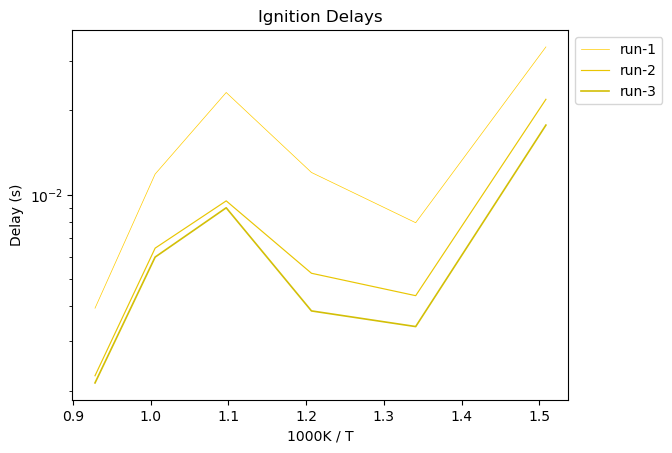

In [9]:
# make ignition delay plot
conditions_dict_path = os.path.join(os.path.dirname(my_chemkin), 'sim_config.yaml')
with open(conditions_dict_path) as f:
    conditions_dict = yaml.safe_load(f)

Ts = np.array([x['T'] for x in conditions_dict['sensitivity_points']])
run_folders = get_prev_run_folders(my_chemkin)
N = len(run_folders)
N = 11
start_color = (1.0, 0.8, 0.0)
end_color = mcolors.hex2color(mcolors.CSS4_COLORS['forestgreen'])
# aramco_color = (0.18627451, 0.48823529, 0.94117647)
colors = sns.blend_palette([start_color, end_color], n_colors=N, as_cmap=False, input='rgb')
lts = np.linspace(0.5, 4.0, N)

for i, run_folder in enumerate(run_folders):
    delays = np.load(os.path.join(run_folder, 'sensitivity', 'base_delays.npy'))
    plt.plot(1000.0 / Ts, delays, label=f'run-{i + 1}', color=colors[i], linewidth=lts[i])


ax = plt.gca()
ax.set_yscale('log')
plt.legend()

plt.title('Ignition Delays')
plt.xlabel('1000K / T')
plt.ylabel('Delay (s)')
plt.legend(bbox_to_anchor=(1, 1))
ignition_plot_file = os.path.join(report_image_dir, 'ign_delay.png')
plt.savefig(ignition_plot_file, bbox_inches='tight')

pdf.cell(200, 10, txt=f'Ignition Delays', ln=True, align='C')
pdf.image(ignition_plot_file, x=50, w=100)


# Make sensitivities plot

C[CH]CC(15) + H2O2(16) <=> HO2(14) + butane(1)
C[CH]CC(15) + H2O2(16) <=> HO2(14) + butane(1)
H2O2(16) + [CH2]CCC(26) <=> HO2(14) + butane(1)
H2O2(16) + [CH2]CCC(26) <=> HO2(14) + butane(1)
H(38) + O2(2) <=> O(5) + OH(27)
H(38) + O2(2) <=> O(5) + OH(27)
OH(27) + butane(1) <=> C[CH]CC(15) + H2O(8)
OH(27) + butane(1) <=> C[CH]CC(15) + H2O(8)
H(38) + butane(1) <=> C[CH]CC(15) + H2(13)
H(38) + butane(1) <=> C[CH]CC(15) + H2(13)


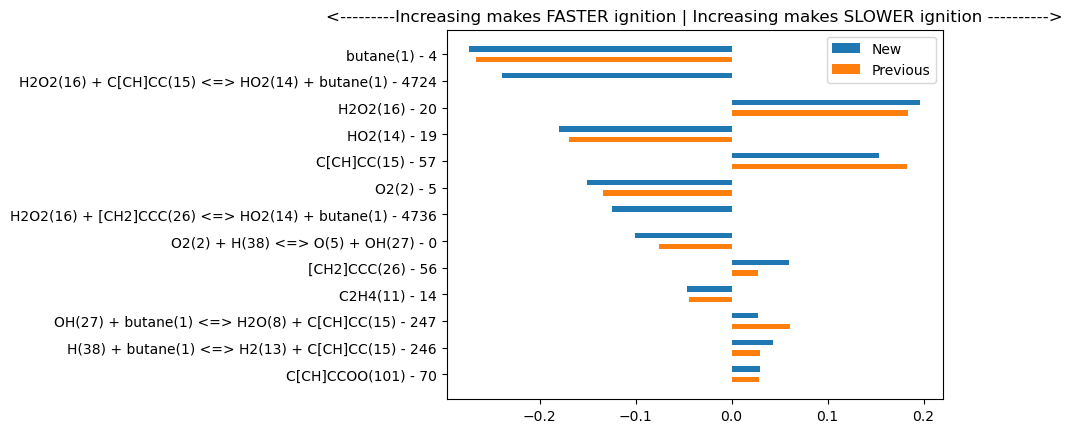

In [29]:
Tmin = 663
Tmax = 1077  # use min and max temperature range of the data: 663K-1077K
N = 51
temperatures = np.linspace(Tmin, Tmax, N)
i_temp = int(np.argmax(np.abs(temperatures - 787)))


sens_current = np.load(os.path.join(run_folders[-1], 'analysis', 'first_derivative.npy'))[:, 6*51 + i_temp]
sens_prev = np.load(os.path.join(run_folders[-2], 'analysis', 'first_derivative.npy'))[:, 6*51 + i_temp]

sens_current[np.isnan(sens_current)] = 0
sens_prev[np.isnan(sens_prev)] = 0

# sort them into order
current_indices = np.arange(0, len(sens_current))
current_sensitivity_order = [x for _, x in sorted(zip(np.abs(sens_current), current_indices))][::-1]

prev_indices = np.arange(0, len(sens_prev))
prev_sensitivity_order = [x for _, x in sorted(zip(np.abs(sens_prev), prev_indices))][::-1]


with open(os.path.join(run_folders[-1], 'ct2rmg_rxn.pickle'), 'rb') as f:
    current_ct2_rmg = pickle.load(f)
with open(os.path.join(run_folders[-2], 'ct2rmg_rxn.pickle'), 'rb') as f:
    prev_ct2_rmg = pickle.load(f)


N_include = 10

# convert from cantera description to RMG
current_items = []
for i in range(N_include):
    j = current_sensitivity_order[i]
    if j < current_gas.n_species:
        current_items.append(species_list_current[j])
    else:
        rmg_index = current_ct2_rmg[j - current_gas.n_species]
        current_items.append(reaction_list_current[rmg_index])

prev_items = []
for i in range(N_include):
    j = prev_sensitivity_order[i]
    if j < prev_gas.n_species:
        prev_items.append(species_list_prev[j])
    else:
        rmg_index = prev_ct2_rmg[j - prev_gas.n_species]
        prev_items.append(reaction_list_prev[rmg_index])


all_items = []
for i in range(len(current_items)):
    all_items.append(current_items[i])

def obj_in_list(obj, my_list):
    for i in range(len(my_list)):
        try:
            if obj.is_isomorphic(my_list[i]):
                return True
        except (ValueError, TypeError):
            pass
    return False

                       
for i in range(len(prev_items)):
    if not obj_in_list(prev_items[i], all_items):
        all_items.append(prev_items[i])

def get_sensitivity(rmg_obj, gas, ct_dict, species_list, reaction_list, sens):

    
    
    if isinstance(rmg_obj, rmgpy.species.Species):
        i_sp = get_i_thing(rmg_obj, species_list)
        if i_sp < 0:
            return 0
        return sens[i_sp]
    i_rxns = get_i_things(rmg_obj, reaction_list)
    if len(i_rxns) == 0:
        return 0
    if len(i_rxns) > 1:
        print('WARNING: multiple sensitive reactions, returning one with largest abs value')

    rxn_sens = []
    for i_rxn in i_rxns:
        assert reactions_in_same_direction(rmg_obj, reaction_list[i_rxn])
        for j in range(len(ct_dict)):
            if ct_dict[j] == i_rxn:
                print(gas.reactions()[j].equation)
                rxn_sens.append(sens[gas.n_species + j])
    i_max = int(np.argmax(np.abs(np.array(rxn_sens))))
    return rxn_sens[i_max]

heights = len(all_items) - np.arange(len(all_items))

current_sens_values = np.zeros(len(all_items))
prev_sens_values = np.zeros(len(all_items))
for i in range(len(all_items)):
    current_sens_values[i] = get_sensitivity(all_items[i], current_gas, current_ct2_rmg, species_list_current, reaction_list_current, sens_current)
    prev_sens_values[i] = get_sensitivity(all_items[i], prev_gas, prev_ct2_rmg, species_list_prev, reaction_list_prev, sens_prev)
            
plt.figure()
width = 0.2
plt.barh(heights + width, current_sens_values, height=width, label='New')
plt.barh(heights - width, prev_sens_values, height=width, label='Previous')
         
        # if k == 0:
        #     label = fig_labels[m]
        
        # plt.barh(k + width * (m - 1.5), final_top_M_sensitivities[k, m], label=label, height=width, align='edge',
        #         alpha=alphas[m], color=colors[m])
#         plt.barh(k + width * (m - 1.5), new_top_M_sensitivities[k, m], label=label, height=width, align='edge',
#                 alpha=alpha, color=colors[m])

# plt.yticks(np.arange(len(set_of_reactions)), [str(int(x)) for x in set_of_reactions])
# plt.yticks(np.arange(len(all_items)))  #, [str(x) for x in all_items)]) # <----- this for SMILES
def get_db_index(obj):
    if isinstance(obj, rmgpy.species.Species):
        return database_fun.get_unique_species_index(obj)
    return database_fun.get_unique_reaction_index(obj)

plt.yticks(heights, [str(x) + ' - ' + str(get_db_index(x)) for x in all_items])  #, ['' for f in final_reaction_labels]) # <----- this for SMILES
plt.title('<---------Increasing makes FASTER ignition | Increasing makes SLOWER ignition ---------->')

plt.legend()
sensitivity_plot_file = os.path.join(report_image_dir, 'sensitivity.png')
plt.savefig(sensitivity_plot_file, bbox_inches='tight')


pdf.cell(200, 10, txt=f'Sensitivity', ln=True, align='C')
pdf.image(sensitivity_plot_file, x=0, w=200)

array([1.97542573e-05, 1.97542573e-05, 1.97542573e-05, ...,
                  nan,            nan,            nan])

# Make species difference plots

not counting failed species 73
not counting failed species 73
not counting failed species 70
not counting failed species 84
not counting failed species 85
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20251028/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20251113/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20251207/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20251223/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20260105/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20260112/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20260210/m

<Figure size 640x480 with 0 Axes>

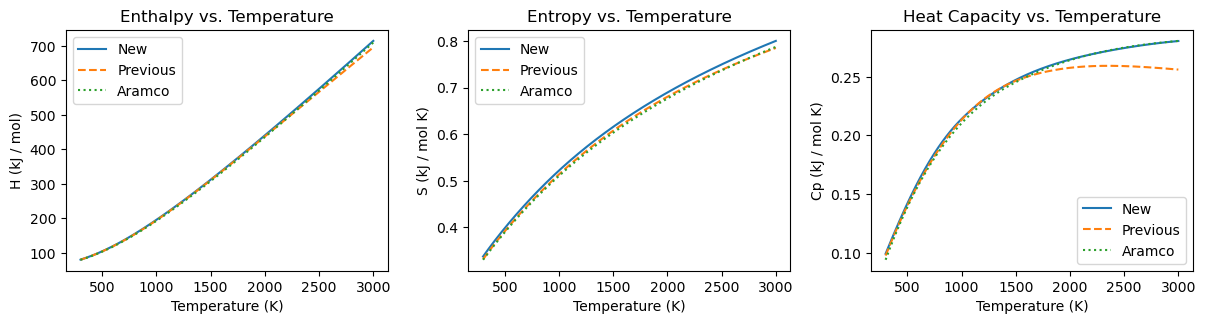

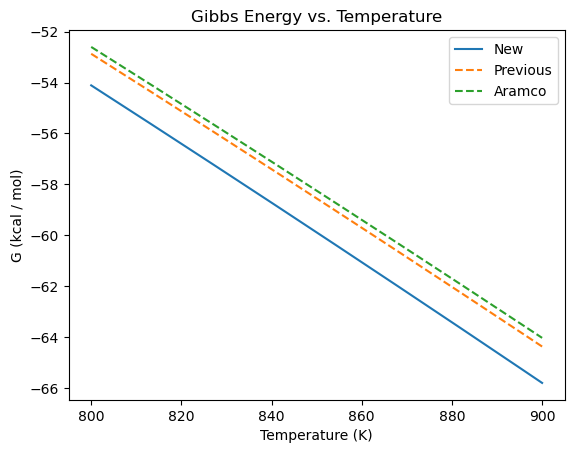

<Figure size 640x480 with 0 Axes>

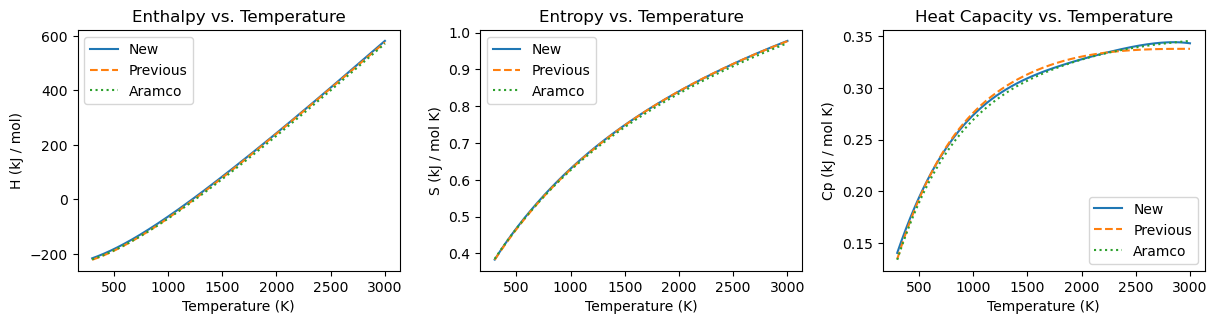

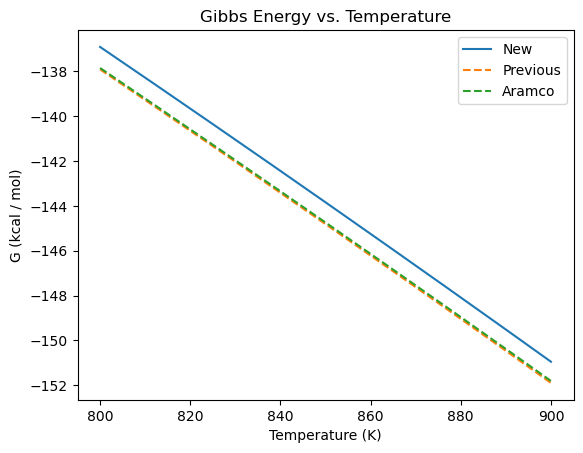

identical thermo


<Figure size 640x480 with 0 Axes>

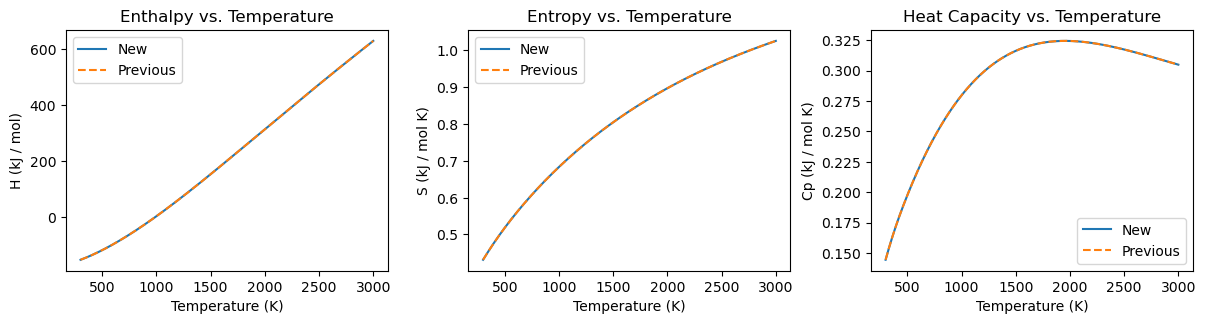

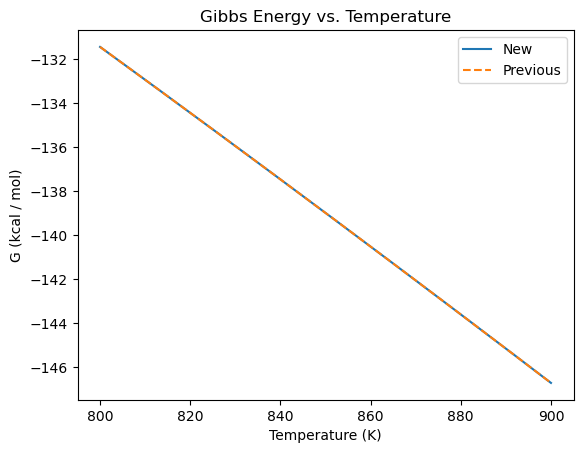

<Figure size 640x480 with 0 Axes>

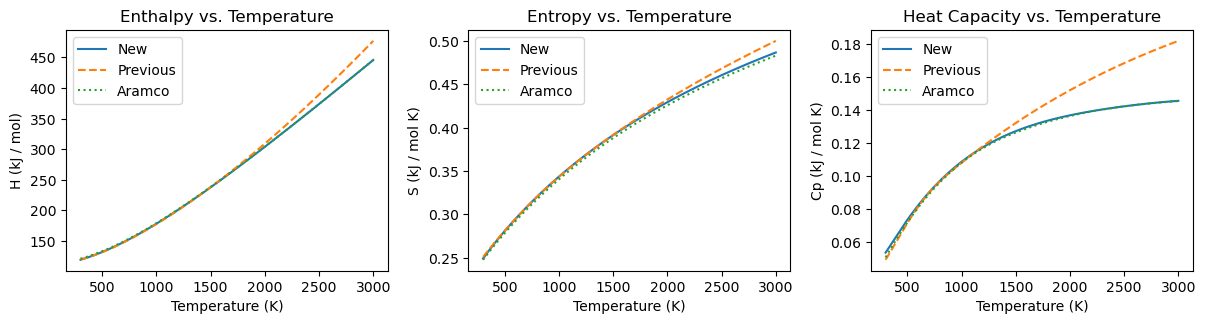

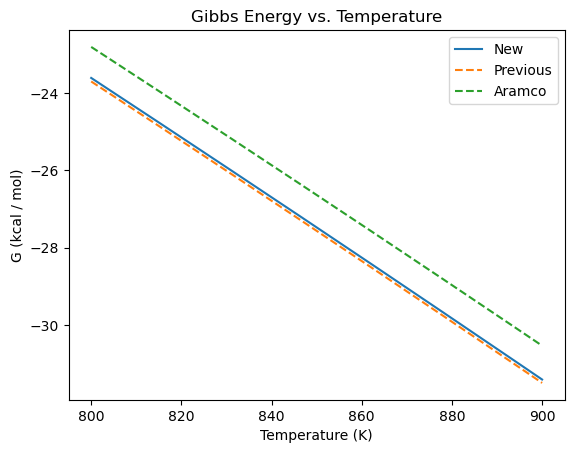

<Figure size 640x480 with 0 Axes>

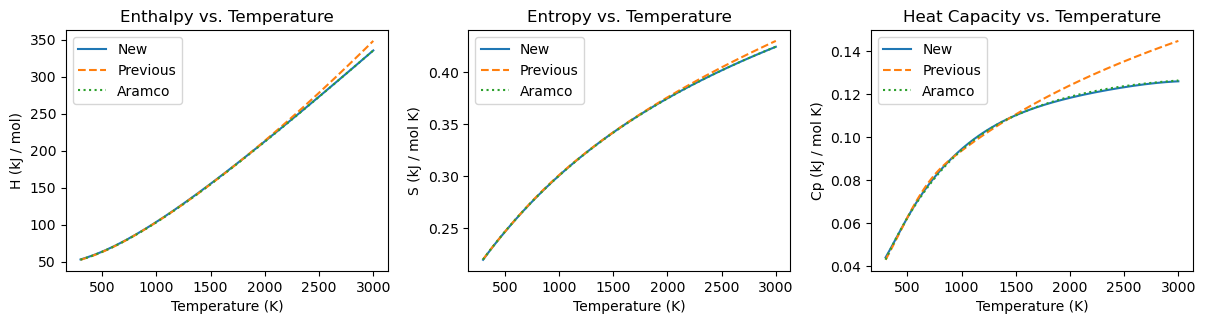

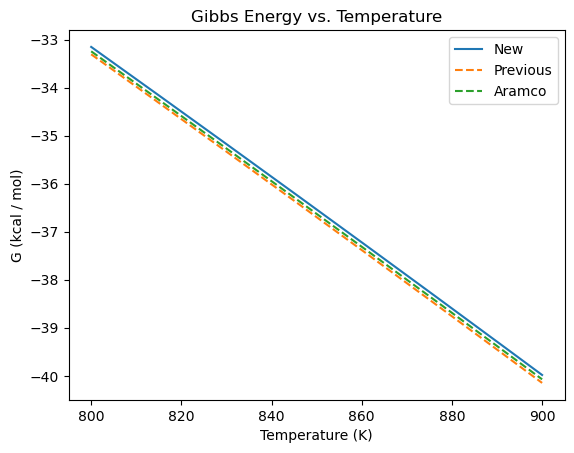

identical thermo


<Figure size 640x480 with 0 Axes>

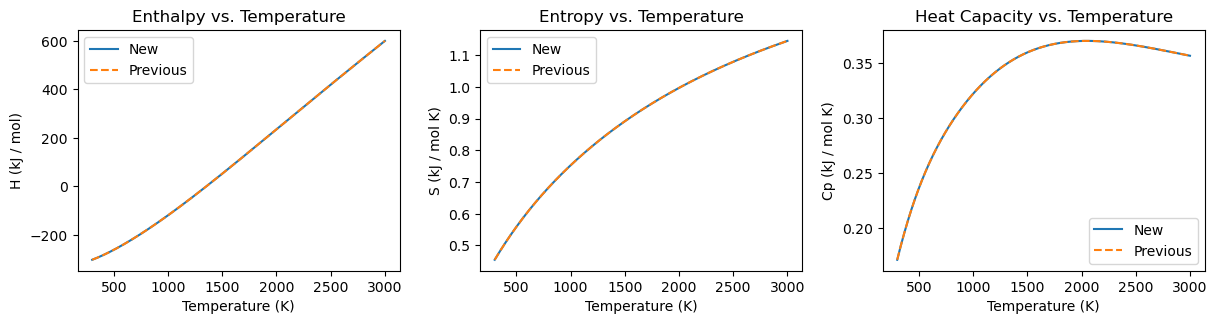

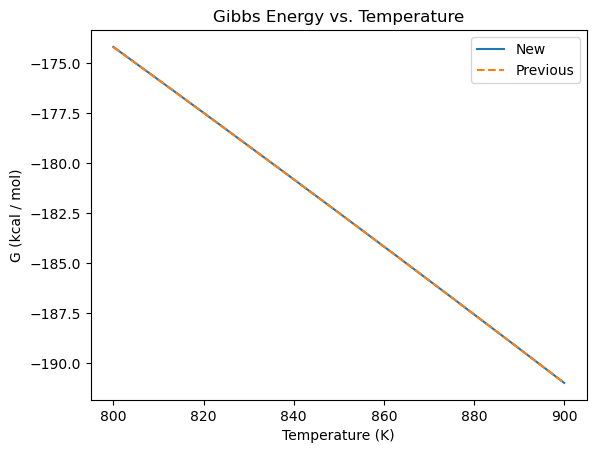

identical thermo


<Figure size 640x480 with 0 Axes>

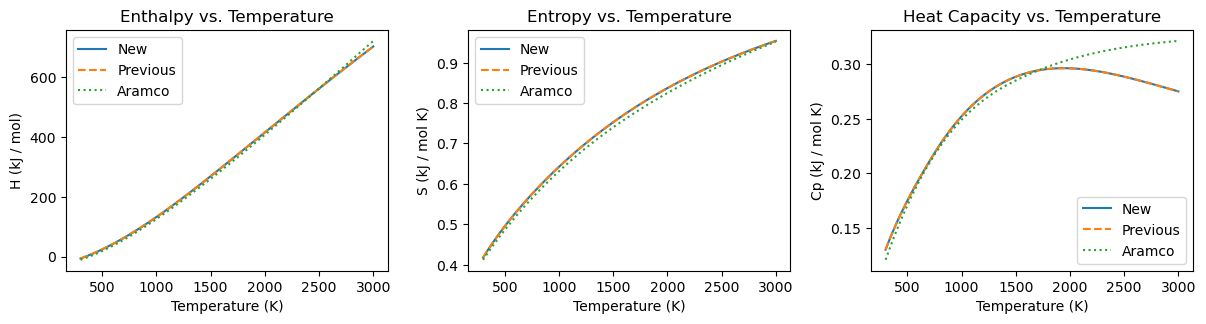

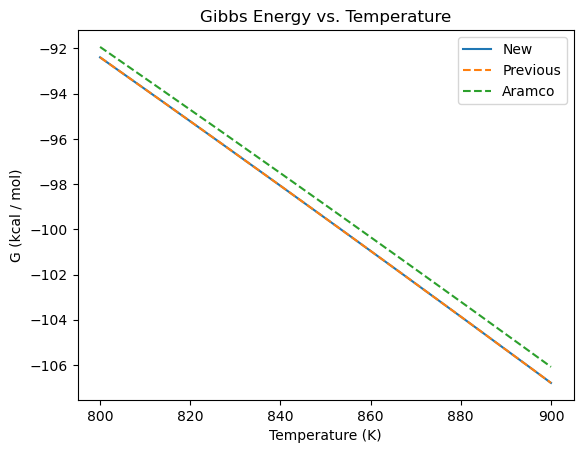

In [26]:
# get the changelists
sp_changelists, rxn_changelists = report.get_changelists(my_chemkin)

run_dirs = get_prev_run_folders(my_chemkin)
assert len(run_dirs) == len(sp_changelists)
assert len(run_dirs) == len(rxn_changelists)

changed_species = sp_changelists[-2]
print(changed_species)

pdf.add_page()
pdf.set_font("Arial", size=24)
pdf.cell(200, 10, txt=f'Changed Species', ln=True, align='C')
pdf.set_font("Arial", size=12)
for i, species_index in enumerate(changed_species):
    ref_sp = database_fun.index2species(species_index)
    ref_sp_img = os.path.join(report_image_dir, f'sp_{species_index:04}.png')
    ref_sp.molecule[0].draw(ref_sp_img)

    pdf.cell(200, 10, txt=f'Species {species_index}', ln=True, align='L')
    pdf.image(ref_sp_img)

    specs = []
    labels = []
    i_current = get_i_thing(ref_sp, species_list_current)
    if i_current >= 0:
        specs.append(species_list_current[i_current])
        labels.append('New')
        
    i_prev = get_i_thing(ref_sp, species_list_prev)
    if i_prev >= 0:
        specs.append(species_list_prev[i_prev])
        labels.append('Previous')
        
    i_A = get_i_thing(ref_sp, species_listA)
    if i_A >= 0:
        specs.append(species_listA[i_A])
        labels.append('Aramco')

    if species_list_current[i_current].get_free_energy(1000) == species_list_prev[i_prev].get_free_energy(1000):
        pdf.set_text_color(255, 0, 0)
        print('identical thermo')
        pdf.cell(200, 10, txt='Thermo is identical -- calculation failed', ln=True, align='L')
        pdf.set_text_color(0, 0, 0)
   

    
    thermo_plot_file = os.path.join(report_image_dir, f'thermo_{species_index:04}.png')
    plot_thermos(specs, labels=labels, fname=thermo_plot_file)
    pdf.image(thermo_plot_file, x=5, w=200)
    
    gibbs_plot_file = os.path.join(report_image_dir, f'gibbs_{species_index:04}.png')
    plot_gibbs(specs, labels=labels, fname=gibbs_plot_file)
    pdf.image(gibbs_plot_file, x=50, w=100)
    
    
    pdf.ln(25)


# make kinetics differences plots

not counting failed species 73
not counting failed species 73
not counting failed species 70
not counting failed species 84
not counting failed species 85
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20251028/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20251113/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20251207/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20251223/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20260105/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20260112/mech_summary.csv
skipping /projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20260210/m

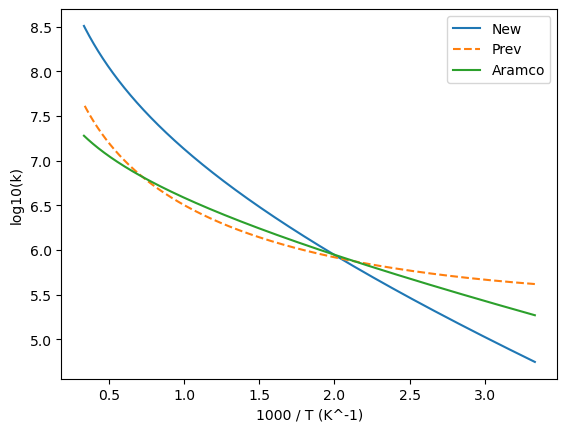

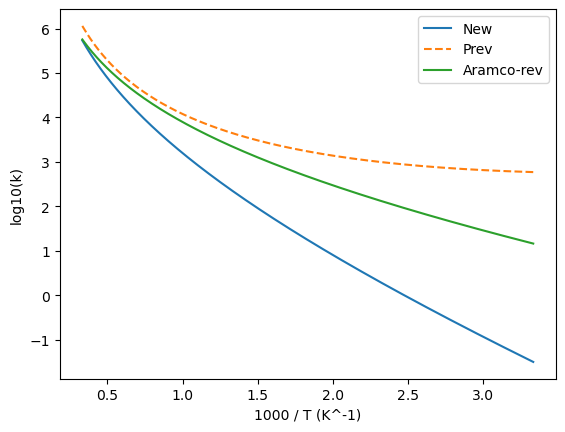

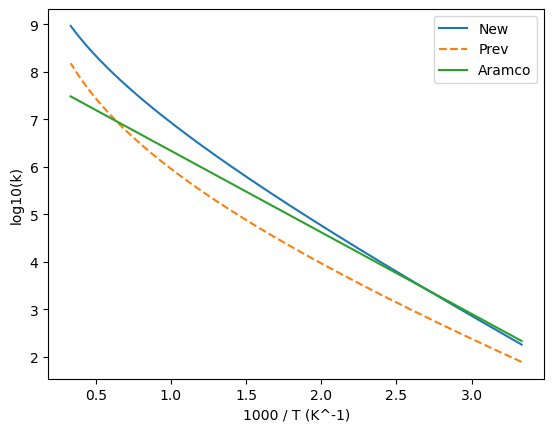

In [27]:
# get the changelists
sp_changelists, rxn_changelists = report.get_changelists(my_chemkin)

run_dirs = get_prev_run_folders(my_chemkin)
assert len(run_dirs) == len(sp_changelists)
assert len(run_dirs) == len(rxn_changelists)

changed_reactions = rxn_changelists[-2]
print(changed_reactions)

pdf.add_page()
pdf.set_font("Arial", size=24)
pdf.cell(200, 10, txt=f'Changed Reactions', ln=True, align='C')
pdf.set_font("Arial", size=12)
for i, reaction_index in enumerate(changed_reactions):
    ref_rxn = database_fun.index2reaction(reaction_index)
    ref_rxn_img = os.path.join(report_image_dir, f'sp_{reaction_index:06}.png')
    ref_rxn.draw(ref_rxn_img)

    pdf.cell(200, 10, txt=f'Reaction {reaction_index}', ln=True, align='L')
    pdf.image(ref_rxn_img)

    fwd_rxns = []
    rev_rxns = []
    fwd_labels = []
    rev_labels = []

    i_currents = get_i_things(ref_rxn, reaction_list_current)
    for j, i_current in enumerate(i_currents):
        label_num = ''
        if j > 0:
            label_num = f'-{j + 1}'
        if reactions_in_same_direction(ref_rxn, reaction_list_current[i_current]):
            fwd_rxns.append(reaction_list_current[i_current])
            rev_rxns.append(get_reverse_reaction(reaction_list_current[i_current]))
            fwd_labels.append(f'New{label_num}')
            rev_labels.append(f'New{label_num}-rev')
        else:
            fwd_rxns.append(get_reverse_reaction(reaction_list_current[i_current]))
            rev_rxns.append(reaction_list_current[i_current])
            fwd_labels.append(f'New{label_num}-rev')
            rev_labels.append(f'New{label_num}')


    i_prevs = get_i_things(ref_rxn, reaction_list_prev)
    for j, i_prev in enumerate(i_prevs):
        label_num = ''
        if j > 0:
            label_num = f'-{j + 1}'
        if reactions_in_same_direction(ref_rxn, reaction_list_prev[i_prev]):
            fwd_rxns.append(reaction_list_prev[i_prev])
            rev_rxns.append(get_reverse_reaction(reaction_list_prev[i_prev]))
            fwd_labels.append(f'Prev{label_num}')
            rev_labels.append(f'Prev{label_num}-rev')
        else:
            fwd_rxns.append(get_reverse_reaction(reaction_list_prev[i_prev]))
            rev_rxns.append(reaction_list_prev[i_prev])
            fwd_labels.append(f'Prev{label_num}-rev')
            rev_labels.append(f'Prev{label_num}')


    i_As = get_i_things(ref_rxn, reaction_listA)
    for j, i_A in enumerate(i_As):
        label_num = ''
        if j > 0:
            label_num = f'-{j + 1}'
        if reactions_in_same_direction(ref_rxn, reaction_listA[i_A]):
            fwd_rxns.append(reaction_listA[i_A])
            rev_rxns.append(get_reverse_reaction(reaction_listA[i_A]))
            fwd_labels.append(f'Aramco{label_num}')
            rev_labels.append(f'Aramco{label_num}-rev')
        else:
            fwd_rxns.append(get_reverse_reaction(reaction_listA[i_A]))
            rev_rxns.append(reaction_listA[i_A])
            fwd_labels.append(f'Aramco{label_num}-rev')
            rev_labels.append(f'Aramco{label_num}')

    
    fwd_kinetics_file = os.path.join(report_image_dir, f'kinetcs_fwd_{reaction_index:06}.png')
    plot_kinetics(fwd_rxns, labels=fwd_labels, fname=fwd_kinetics_file)
    pdf.image(fwd_kinetics_file, x=50, w=100)
    
    pdf.ln(25)


In [28]:
pdf.output("output.pdf")

''